In [16]:
from Bio import SeqIO
from Bio import AlignIO
import sys, os, tempfile
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import numpy as np
import itertools
import os, gzip, shutil, glob
from io import StringIO
import re
from Bio.Blast import NCBIXML
import ast

### VIZ function

In [104]:
def VIZ(mapping, windows, yname, xname, svgname, save=True):
    BladeTHUs1_7 = [1,1304]
    Beam = [1305,1367]
    Central_plug = [1368,1401]
    Lateral_plug=[1402, 1411]
    Latch=[1412,1425]
    Latch2Clasp=[1426,1514]
    Clasp=[1515,1570]
    Clasp2THU8=[1571,1656]
    BladeTHUs8_9=[1657,2098]
    Anchor=[2099,2165]
    OuterHelix=[2166,2193]
    Cap=[2194,2439]
    InnerHelix=[2440,2473]
    CTD=[2474,2521]
    
    colors_12 = px.colors.qualitative.Light24[:14]
    
    regions = [
        ("BladeTHUs1_7",   BladeTHUs1_7, colors_12[0]),
        ("Beam",           Beam, colors_12[1]),
        ("Central_plug",   Central_plug, colors_12[2]),
        ("Lateral_plug",   Lateral_plug, colors_12[3]),
        ("Latch",          Latch, colors_12[4]),
        ("Latch2Clasp",    Latch2Clasp, colors_12[5]),
        ("Clasp",          Clasp, colors_12[6]),
        ("Clasp2THU8",     Clasp2THU8, colors_12[7]),
        ("BladeTHUs8_9",   BladeTHUs8_9, colors_12[8]),
        ("Anchor",         Anchor, colors_12[9]),
        ("OuterHelix",     OuterHelix, colors_12[10]),
        ("Cap",            Cap, colors_12[11]),
        ("InnerHelix",     InnerHelix, colors_12[12]),
        ("CTD",            CTD, colors_12[13]),
    ]
    x = np.arange(1, 2522)
    colors = np.full(len(x), "lightgray", dtype=object)
    
    for name, start_end, color in regions:
        mask = (x >= start_end[0]) & (x <= start_end[-1])
        colors[mask] = color
        
    y = list(mapping.values())
    y_arr = np.array(y)
    
    # print("len(colors), len(y_arr), len(x)", len(colors), len(y_arr), len(x))

    vz_df = pd.DataFrame({
    'x': x,
    'y_arr': y_arr,
    'color': colors
    })

    # regression
    from sklearn.tree import DecisionTreeRegressor
    from sklearn.ensemble import AdaBoostRegressor
    regr = AdaBoostRegressor(
        DecisionTreeRegressor(max_depth=4), n_estimators=300, random_state=42
    )
    regr.fit(x.reshape(-1, 1), y_arr)
    y_fit = regr.predict(x.reshape(-1, 1))
    fit_df = pd.DataFrame({
        'x': x,
        'y_fit': y_fit,
        'color': colors
    })
    window_size = windows  # Adjust the window size as needed
    y_smooth = np.convolve(y_arr, np.ones(window_size)/window_size, mode='valid')

    figBar = px.bar(vz_df, y='y_arr', x='x',  color="color", color_discrete_map="identity")
    figBar.update_layout(
        xaxis_title=xname,
        yaxis_title=yname,
        bargap=0,
        bargroupgap=0,
        width=1200,
        height=300,
        paper_bgcolor="rgba(0,0,0,0)",
        plot_bgcolor="rgba(0,0,0,0)",
        margin=dict(l=20, r=20, t=0, b=0),
        showlegend=True
    )
    figBar.add_trace(
        go.Scatter(
            x=vz_df['x'][window_size-1:],  # Align x-axis to the smoothed data (to match length)
            y=y_smooth,
            mode='lines',
            name='Smoothed Trend',
            line=dict(color='black', width=0.7),
            showlegend=False
        )
    )
    for region_name, start_end, color in regions:
        figBar.add_trace(
            go.Scatter(
                x=start_end,  # Position the region on the x-axis
                y=[max(vz_df['y_arr'])] * 2,  # Use max y to position the legend
                mode='lines',
                line=dict(color=color, width=10),
                name=region_name
            )
        )
    figBar.add_vline(x=1305, line_width=2, line_dash="dash", line_color="black")
    figBar.add_vline(x=2156, line_width=2, line_dash="dash", line_color="black")
    figBar.add_vline(x=2210, line_width=2, line_dash="dash", line_color="black")
    figBar.add_vline(x=2428, line_width=2, line_dash="dash", line_color="black")

    # Update layout to add the legend at the bottom
    figBar.update_layout(
        xaxis_title=xname,
        yaxis_title=yname,
        xaxis_title_font=dict(size=11),
        yaxis_title_font=dict(size=11),
        bargap=0,
        bargroupgap=0,
        width=1100,
        height=300,
        paper_bgcolor="rgba(0,0,0,0)",
        plot_bgcolor="rgba(0,0,0,0)",
        margin=dict(l=20, r=20, t=0, b=100),  # Increased bottom margin to fit the legend
        showlegend=True,
        legend=dict(
            orientation='h',  # Horizontal legend at the bottom
            x=0,              # Align the legend to the left
            y=-0.5,           # Place the legend below the plot
            xanchor='left',
            yanchor='top',
            font=dict(size=10)
        )
    )
    figBar.update_xaxes(
        tickmode="array",
        tickvals=[500, 1000, 1304, 1500, 2000, 2156, 2210, 2428, 2500],              # only one tick
        ticktext=["500", "1000", "<b>1305</b>", "1500", "2000", "<b>2156</b>", "<b>2210</b>", "<b>2428</b>", "2500"],     # bold number (HTML works)
        tickfont=dict(
            color="black",
            size=10
        ),
        showline=True,
        linecolor="black",
        linewidth=1,
        ticks="outside"
    )
    # figBar.update_traces(width=1)
    if save:
        figBar.write_image(svgname)
        #figBar.write_html(svgname)
    figBar.show()

### load original data 55

In [89]:
def fasta_to_df(fasta_file, source_name):
    records = SeqIO.parse(fasta_file, "fasta")
    data = []
    
    for record in records:
        data.append({
            "source": source_name,
            "id": record.id,
            "description": record.description,
            "sequence": str(record.seq),
            "length": len(record.seq)
        })
    
    return pd.DataFrame(data)

In [90]:
rcsb_file = "./up2nowPiezoFasta/rcsb_pdb_20251203050858.fasta"
TCDB_file = "./up2nowPiezoFasta/TCDB_piezo.fasta"
uniprot_file = "./up2nowPiezoFasta/uniprotkb_accession_A0A061ACU2_OR_access_2025_12_03.fasta"
rcsb_sequences = list(SeqIO.parse(rcsb_file, "fasta"))
TCDB_sequences = list(SeqIO.parse(TCDB_file, "fasta"))
uniprot_sequences = list(SeqIO.parse(uniprot_file, "fasta"))

In [91]:
len(rcsb_sequences), len(TCDB_sequences), len(uniprot_sequences), len(rcsb_sequences+TCDB_sequences+uniprot_sequences)

(20, 26, 9, 55)

In [92]:
df_rcsb = fasta_to_df(rcsb_file, "RCSB")
df_tcdb = fasta_to_df(TCDB_file, "TCDB")
df_uniprot = fasta_to_df(uniprot_file, "UniProt")
df_all = pd.concat([df_rcsb, df_tcdb, df_uniprot], ignore_index=True)

In [93]:
# with open("up2now_piezo55.fasta", "w") as f:
#     for _, row in df_all.iterrows():
#         f.write(f">{row['id']}\n{row['sequence']}\n")

#### this sub-code is used to find those sequences without 3D structure, and I have to predicted their 3D structure using AlphaFold server

In [7]:
cdhit_df = pd.read_csv("./up2now_piezo_distinct_CDHIT.csv")
AI3Did_lst = cdhit_df[cdhit_df["D3"]==1]["identifier"].tolist()
len(AI3Did_lst)

15

In [8]:
AI3Did_lst

['CEL94374.1',
 'tr|G7YE70|G7YE70_CL',
 'sp|Q54S52|Y2801_DIC',
 'KRX01930.1',
 'EWM21785.1',
 'tr|Q9VLS3|Q9VLS3_DR',
 'XP_015659765.1',
 'XP_024369685.1',
 'tr|E9BU59|E9BU59_LE',
 'tr|A0D620|A0D620_PA',
 'XP_022839111.1',
 'tr|C4LXG0|C4LXG0_EN',
 'tr|F1KPQ0|F1KPQ0_AS',
 'CUG89832.1',
 'KHN03769.1']

In [9]:
def extract_id(i):
    if "." in i:
        return i.split(".", 1)[0]
    elif "|" in i:
        return i.split("|")[1]
    else:
        return i

In [30]:
# for ID_incomplete in AI3Did_lst:
#     filename = extract_id(ID_incomplete)
#     out_file = f"./unknown3D/{filename}.fasta"
#     print(f"Writing {out_file}")

#     with open(out_file, "w") as f:
#         for _, row in df_all.iterrows():
#             if ID_incomplete in row["id"]:
#                 print(len(row['sequence']))
#                 f.write(f">{row['id']}\n{row['sequence']}\n")


## filter to 31 via CD-HIT where c=0.9

In [94]:
cdhit_df = pd.read_csv("./up2now_piezo_distinct_CDHIT.csv")
identifier_list = cdhit_df[cdhit_df["is_representative"]==True]["identifier"].tolist()
ID_seq_dict = {}
for i in identifier_list:
    for _, row in df_all.iterrows():
        IDfull = row["id"]
        if i in IDfull:
            ID_seq_dict[IDfull] = row["sequence"]

# with open("up2now_piezo31.fasta", "w") as f:
#     for k, v in ID_seq_dict.items():
#         f.write(f">{k}\n{v}\n")

In [95]:
len(ID_seq_dict)

31

## seq alignment via Blastp

In [96]:
blast_seq_mapping = {i: 0 for i in range(2521)}
with open("./query_blastp_target30_fmt5.xml") as f:
    records = NCBIXML.parse(f)
    for record in records:
        for alignment in record.alignments:
            print("Target:", alignment.hit_def)
            picked_pos = []
            for hsp in alignment.hsps:
                Q, Q_st, Q_ed = hsp.query, hsp.query_start, hsp.query_end
                S, S_st, S_ed = hsp.sbjct, hsp.sbjct_start, hsp.sbjct_end
                c = 0
                for idx, aa in enumerate(Q, start=0):
                    count_ = Q[:idx].count("-")

                    if aa != "-" and S[idx] != "-":
                        picked_pos.append(idx + Q_st - 1 - count_)
            for p in picked_pos:
                blast_seq_mapping[p] += 1


Target: 6B3R_1|Chains
Target: 6LQI_1|Chains
Target: sp|Q9H5I5|PIEZ2_HUMAN
Target: 6KG7_1|Chains
Target: sp|M9MSG8|PIEZO_DROME
Target: tr|Q9VLS3|Q9VLS3_DROME
Target: tr|G7YE70|G7YE70_CLOSI
Target: tr|F1KPQ0|F1KPQ0_ASCSU
Target: sp|A0A061ACU2|PIEZ1_CAEEL
Target: XP_024369685.1
Target: sp|Q54S52|Y2801_DICDI
Target: tr|C4LXG0|C4LXG0_ENTHI
Target: EWM21785.1
Target: sp|F4IN58|PIEZO_ARATH
Target: tr|Q4DXU9|Q4DXU9_TRYCC
Target: tr|A0D620|A0D620_PARTE
Target: KHN03769.1
Target: CEL94374.1
Target: tr|E9BU59|E9BU59_LEIDB
Target: KRX01930.1
Target: XP_015659765.1
Target: XP_022839111.1


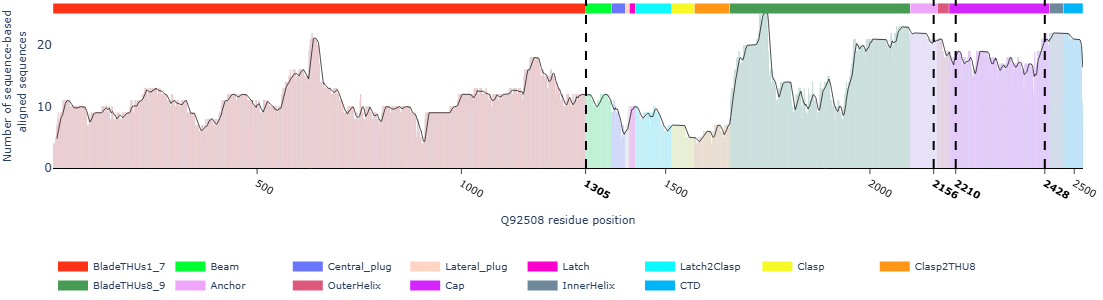

In [105]:
VIZ(mapping=blast_seq_mapping, windows=10, yname="Number of sequence-based <br> aligned sequences", xname="Q92508 residue position",svgname="./seq_bar.svg")


## Structue alignment and viz

In [219]:
# ## roginal name 2 daliname
# def generate_unique_names():
#     # Create a pool of characters: A-Z, 0-9
#     characters = 'abcdefghijklmnopqrstuvwxyz0123456789'
#     # Generate all combinations of 4 characters
#     unique_names = [''.join(comb) for comb in itertools.product(characters, repeat=4)]
#     return unique_names

# unique_names = generate_unique_names()

# orginalPDB_path = "./PDB/"
# orginalPDB_fps = glob.glob(os.path.join(orginalPDB_path, "*.pdb"))
# daliPDB_path = "./daliPDB/"

# orig2dali_rows = [] 

# for i in range(len(orginalPDB_fps)):
#     fp = orginalPDB_fps[i]
#     origname = fp.split("\\")[-1]
#     daliname = unique_names[i]
#     row = {"orginalPDB":origname, "daliPDB":daliname}
#     orig2dali_rows.append(row)
#     shutil.copyfile(fp, daliPDB_path + daliname + ".pdb")


In [220]:
# orig2dali_df = pd.DataFrame(orig2dali_rows)
# orig2dali_df.to_csv("orig2dali_df.csv")

In [81]:
# for name in os.listdir("./daliAlign"):
#     dir_path = os.path.join("./daliAlign/", name)
#     if name.startswith("aaamA_vs_") and os.path.isdir(dir_path):
#         src_file = os.path.join(dir_path, "aaamA.txt")

#         if os.path.isfile(src_file):
#             dst_file = os.path.join("./daliAlign/", f"{name}_aaamA.txt")
#             shutil.copyfile(src_file, dst_file)
#         else:
#             print(f"[WARN] aaamA.txt not found in {name}")

In [107]:
def parse_daliAlign(fp):
    Q = ""
    S = ""
    with open(fp, "r") as f:
        for line in f:
            line = line.rstrip("\n")
            if line[:5] == "Query":
                Q += line.split(" ")[1]
            elif line[:5] == "Sbjct":
                S += line.split(" ")[1]
            else:
                pass
    return Q, S

In [108]:
len(glob.glob("./daliAlign/*.txt"))

30

In [109]:
structure_mapping = {i: 0 for i in range(2521)}
for fp in glob.glob("./daliAlign/*.txt"):
    Q, S = parse_daliAlign(fp)
    if len(Q) != 0:
        ref_pos = -1
        for idx, aa in enumerate(Q, start=0):
            if aa != "-":
                ref_pos += 1
                if S[idx] != "-":
                    structure_mapping[ref_pos] += 1
    else:
        print(fp)
                


./daliAlign\aaamA_vs_aaahA_aaamA.txt
./daliAlign\aaamA_vs_aaajA_aaamA.txt
./daliAlign\aaamA_vs_aaanA_aaamA.txt
./daliAlign\aaamA_vs_aaapA_aaamA.txt


In [110]:
len(structure_mapping)

2521

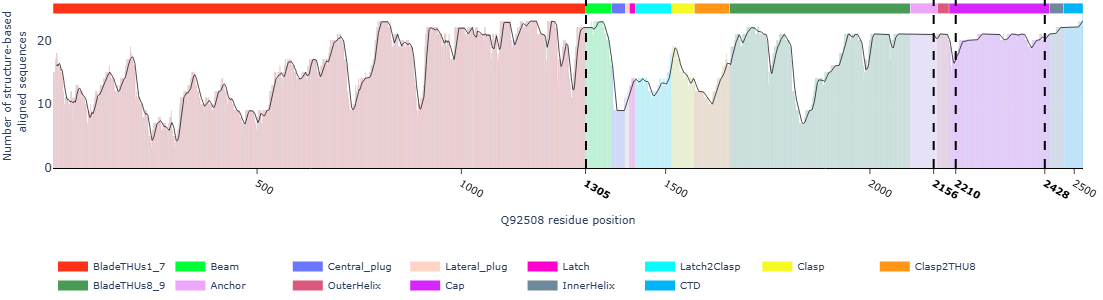

In [111]:
VIZ(mapping=structure_mapping, windows=10, yname="Number of structure-based <br> aligned sequences", xname="Q92508 residue position",svgname="./stru_bar.svg")

## Topology

In [9]:
def plain_viz(y0, y1, df):
    fig = go.Figure()
    centers_list_tmp = df["center"].tolist()
    # centers_list = [ast.literal_eval(item) for item in centers_list_tmp]
    CENTERS_arr = np.asarray(centers_list_tmp)
    xs = CENTERS_arr[:, 0]
    ys = CENTERS_arr[:, 1]

    fig.add_trace(
            go.Scatter(
                    x=xs,
                    y=ys,
                    mode="lines+markers+text",
                    line=dict(shape="spline", width=2, color="cornflowerblue"),
                    marker=dict(size=10, color="cornflowerblue"),
                    hovertext=df["position"].astype(str) + df["AA"],
                    hoverinfo="text",
                    showlegend=False,
                )
                )
    fig.add_hrect(y0=y0, y1=y1, line_width=0, fillcolor="tan", opacity=0.5, layer="below")
    NtermAA_x, NtermAA_y = xs[0], ys[0]
    fig.add_annotation(x=NtermAA_x, y=NtermAA_y, text="N<sub>2</sub>H-", showarrow=False, xshift=-30)
    CtermAA_x, CtermAA_y = xs[-1], ys[-1]
    fig.add_annotation(x=CtermAA_x, y=CtermAA_y, text="-COOH", showarrow=False, xshift=30)

    fig.update_xaxes(visible=False)
    fig.update_yaxes(visible=False)
    fig.update_layout(
        paper_bgcolor="rgba(0,0,0,0)", 
        plot_bgcolor="rgba(0,0,0,0)", 
        autosize=True,
        margin=dict(l=20, r=20, t=0, b=0),
        showlegend=True
            )
    fig.show()

In [21]:
TopoDataFrame = pd.read_csv("./TopologyCenters.csv")
centers_list_tmp = TopoDataFrame["center"].tolist()
centers_list = [ast.literal_eval(item) for item in centers_list_tmp]
CENTERS_arr = np.asarray(centers_list)

xs = CENTERS_arr[:, 0]
ys = CENTERS_arr[:, 1]

y0=2.0 
y1=4.821227555116749

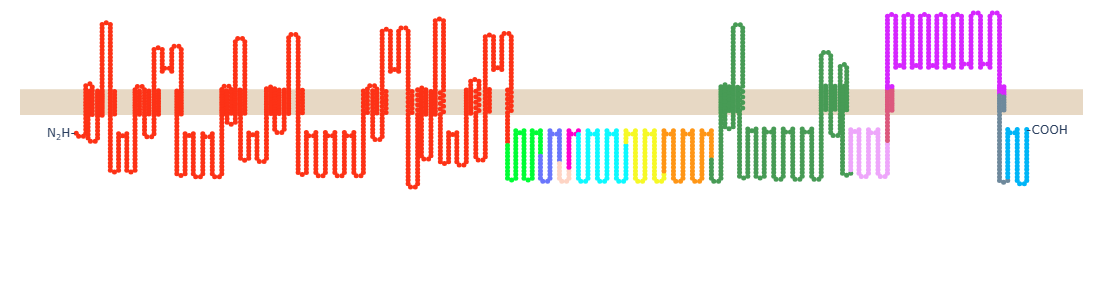

In [48]:
fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=xs,
        y=ys,
        mode="lines+markers+text",
        line=dict(shape="spline", width=1, color="lightgray"),
        marker=dict(size=5, color=marker_colors)
    )
)
fig.add_hrect(y0=y0, y1=y1, line_width=0, fillcolor="tan", opacity=0.5, layer="below", row=1, col=1)
NtermAA_x, NtermAA_y = xs[0], ys[0]
fig.add_annotation(x=NtermAA_x, y=NtermAA_y, text="N<sub>2</sub>H-", showarrow=False, xshift=-15)
CtermAA_x, CtermAA_y = xs[-1], ys[-1]
fig.add_annotation(x=CtermAA_x, y=CtermAA_y, text="-COOH", showarrow=False, xshift=20)
fig.update_xaxes(
    showgrid=False,
    zeroline=False,
    showline=False,
    ticks="",
    showticklabels=False,
    visible=False
)
fig.update_yaxes(
    showgrid=False,
    zeroline=False,
    showline=False,
    ticks="",
    showticklabels=False,
    visible=False
)
fig.update_layout(
    width=1050,
    height=300,
    paper_bgcolor="rgba(0,0,0,0)",
    plot_bgcolor="rgba(0,0,0,0)",
    margin=dict(l=20, r=20, t=0, b=100),  # Increased bottom margin to fit the legend
)
fig.write_image("topo.svg")
fig.show()

In [43]:
BladeTHUs1_7 = [1,1304]
Beam = [1305,1367]
Central_plug = [1368,1401]
Lateral_plug=[1402, 1411]
Latch=[1412,1425]
Latch2Clasp=[1426,1514]
Clasp=[1515,1570]
Clasp2THU8=[1571,1656]
BladeTHUs8_9=[1657,2098]
Anchor=[2099,2165]
OuterHelix=[2166,2193]
Cap=[2194,2439]
InnerHelix=[2440,2473]
CTD=[2474,2521]

colors_12 = px.colors.qualitative.Light24[:14]
    
regions = [
    ("BladeTHUs1_7",   BladeTHUs1_7, colors_12[0]),
    ("Beam",           Beam, colors_12[1]),
    ("Central_plug",   Central_plug, colors_12[2]),
    ("Lateral_plug",   Lateral_plug, colors_12[3]),
    ("Latch",          Latch, colors_12[4]),
    ("Latch2Clasp",    Latch2Clasp, colors_12[5]),
    ("Clasp",          Clasp, colors_12[6]),
    ("Clasp2THU8",     Clasp2THU8, colors_12[7]),
    ("BladeTHUs8_9",   BladeTHUs8_9, colors_12[8]),
    ("Anchor",         Anchor, colors_12[9]),
    ("OuterHelix",     OuterHelix, colors_12[10]),
    ("Cap",            Cap, colors_12[11]),
    ("InnerHelix",     InnerHelix, colors_12[12]),
    ("CTD",            CTD, colors_12[13]),
]

default_color = "lightgray"

marker_colors = []

for i in range(len(xs)):
    color = default_color
    for _, (start, end), region_color in regions:
        if start <= i+1 <= end:
            if i+1 in [1305, 2156, 2210, 2428]:
                color = region_color
                break
            else:
                color = region_color
                break
    marker_colors.append(color)

In [49]:
colors_12

['#FD3216',
 '#00FE35',
 '#6A76FC',
 '#FED4C4',
 '#FE00CE',
 '#0DF9FF',
 '#F6F926',
 '#FF9616',
 '#479B55',
 '#EEA6FB',
 '#DC587D',
 '#D626FF',
 '#6E899C',
 '#00B5F7']

In [84]:
def getLegend(name, color ):
    fig1 = go.Figure()
    
    # Draw a square
    fig1.add_shape(
        type="rect",
        x0=0, y0=0,
        x1=0.25, y1=0.25,
        fillcolor=color,
        line=dict(color=color)
    )
    
    # Add text to the right
    fig1.add_annotation(
        x=0.25+0.01,
        y=0.125,
        text=name,
        showarrow=False,
        xanchor="left",
        yanchor="middle",
        font=dict(size=10)
    )
    
    # Layout cleanup
    fig1.update_layout(
        width=130,
        height=20,
        xaxis=dict(visible=False, range=[-0.1, 1.5]),
        yaxis=dict(visible=False, range=[-0.1, 0.5]),
        plot_bgcolor="white",
        paper_bgcolor="white",
        margin=dict(l=0, r=0, t=0, b=0)
    )
    fig1.write_image(name+".svg")
    fig1.show()

for name, _, region_color in regions:
    getLegend(name, region_color)
    

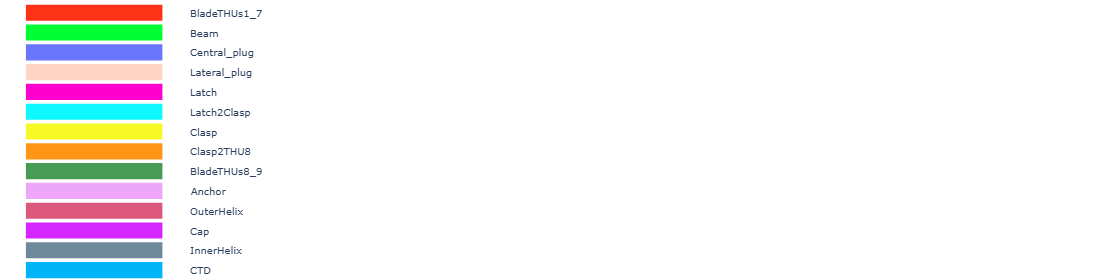

In [117]:
fig2 = go.Figure()
n = len(regions)
box_size=0.25
row_h=0.35
font_size=10
for i, (name, _, color) in enumerate(regions):
    y0 = (n - 1 - i) * row_h 
    y1 = y0 + box_size

    # colored square
    fig2.add_shape(
        type="rect",
        x0=0, y0=y0,
        x1=box_size, y1=y1,
        fillcolor=color,
        line=dict(color=color)
    )

    # label text (to the right of square)
    fig2.add_annotation(
        x=box_size + 0.05,
        y=(y0 + y1) / 2,
        text=name,
        showarrow=False,
        xanchor="left",
        yanchor="middle",
        font=dict(size=font_size)
    )

n = len(regions)
total_h = max(1e-9, n * row_h)

fig2.update_layout(
    width=180,
    height=max(20, int(20 * n)),   # simple scaling; adjust as desired
    xaxis=dict(visible=False, range=[-0.05, 2.0]),
    yaxis=dict(visible=False, range=[-0.05, total_h]),
    plot_bgcolor="white",
    paper_bgcolor="white",
    margin=dict(l=0, r=0, t=0, b=0),
)

fig2.write_image("legend.svg")
fig2.show()